<div>
Olá, Thaís!

Meu nome é Luiz. Fico feliz em revisar seu projeto. Ao longo do texto farei algumas observações sobre melhorias no código e também farei comentários sobre suas percepções sobre o assunto. Estarei aberto a feedbacks e discussões sobre o tema.

**Peço que mantenha e não altere os comentários que eu fizer por aqui para que possamos nos localizar posteriormente, ok?**

Mais uma coisa, vamos utilizar um código de cores para você entender o meu feedback no seu notebook. Funciona assim:

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

Sucesso. Tudo foi feito corretamente.
</div>

<div class="alert alert-block alert-warning">
<b>Comentário do revisor: </b> <a class="tocSkip"></a>

Alerta não crítico, mas que pode ser corrigido para melhoria geral no seu código/análise.
</div>

<div class="alert alert-block alert-danger">

<b>Comentário do revisor: </b> <a class="tocSkip"></a>
    
Erro que precisa ser arrumado, caso contrário seu projeto **não** será aceito.
</div>

Você pode interagir comigo através dessa célula:
<div class="alert alert-block alert-info">
<b>Resposta do Aluno.</b> <a class="tocSkip"></a>
</div>

<div class="alert alert-block alert-danger">
<b> Comentário geral do revisor v1</b> <a class="tocSkip"></a>
<s>
    
Obrigado por enviar o seu projeto e pelo esforço de chegar até aqui. O seu projeto possui alguns pontos bem interessantes, dos quais eu destaco:
    
- Código bem simples e estruturado 
- Comentários sucintos e bem objetivos
- Conclusões pertinentes em cada análise e etapa de avaliação
    
Entretanto, deixei alguns comentários em alguns trechos que precisam de ajuste. Peço que trabalhe nesses pontos para avançarmos.
    
Qualquer dúvida, pode contar comigo.   
    
    
**Até breve!**
</s>
</div>

<div class="alert alert-block alert-success">
<b> Comentário geral do revisor</b> <a class="tocSkip"></a>

Obrigado por enviar o seu projeto e fazer os ajustes sugeridos. Essa versão do seu trabalho ficou muito melhor! Espero que as sugestões sejam relevantes para projetos futuros.
    
<br>
Te desejo uma jornada de muito sucesso e aprendizado.
    
<br>   
    
Qualquer dúvida, pode contar comigo.   
    
<br>  
    
**Até breve!**

</div>

# Project Name: When Customers Leave: A Predictive Churn Analysis


# Data Preparation

The initial step of the project focuses on data preparation. This includes loading the dataset, understanding its structure, verifying data types, checking for missing values, and standardizing column names to ensure clarity and consistency throughout the analysis.
 

1) Load and Preparing the Data

In [1]:
# import 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Read the dataset
churn = pd.read_csv("/datasets/Churn.csv")

print(churn.head())

   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0     2.0       0.00              1          1               1   
1     1.0   83807.86              1          0               1   
2     8.0  159660.80              3          1               0   
3     1.0       0.00              2          0               0   
4     2.0  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  
4         790

In [3]:
print(churn.shape)

(10000, 14)


<div class="alert alert-block alert-warning">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

- Os arquivos de dados foram carregados corretamente
- A importação das bibliotecas foi feita em células separadas. Sugestão: execute os comandos acima em células separadas para isolar a execução do código.
</div>


<div class="alert alert-block alert-info">

<b> Comando em celulas separadas.</b> <a class="tocSkip"></a>
</div>




In [4]:
# Inspect dataset
print(churn.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           9091 non-null   float64
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(3), int64(8), object(3)
memory usage: 1.1+ MB
None


In [5]:
# Rename columns
churn.rename(columns={
    'RowNumber': 'row_number',
    'CustomerId': 'customer_id',
    'Geography': 'country',
    'NumOfProducts': 'num_of_products',
    'HasCrCard': 'has_crcard',
    'IsActiveMember': 'is_active_member',
    'EstimatedSalary': 'estimated_salary',
    'Exited': 'churn'
}, inplace=True)

churn.columns = churn.columns.str.lower()

In [6]:
churn.describe()

,row_number,customer_id,creditscore,age,tenure,balance,num_of_products,has_crcard,is_active_member,estimated_salary,churn
count,10000.00000,1.000000e+04,10000.000000,10000.000000,9091.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,4.997690,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.894723,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,2.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


<div class="alert alert-block alert-danger">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>
<s>
    
- Aqui você precisa fazer uma análise exploratória inicial dos dados. Exemplo:

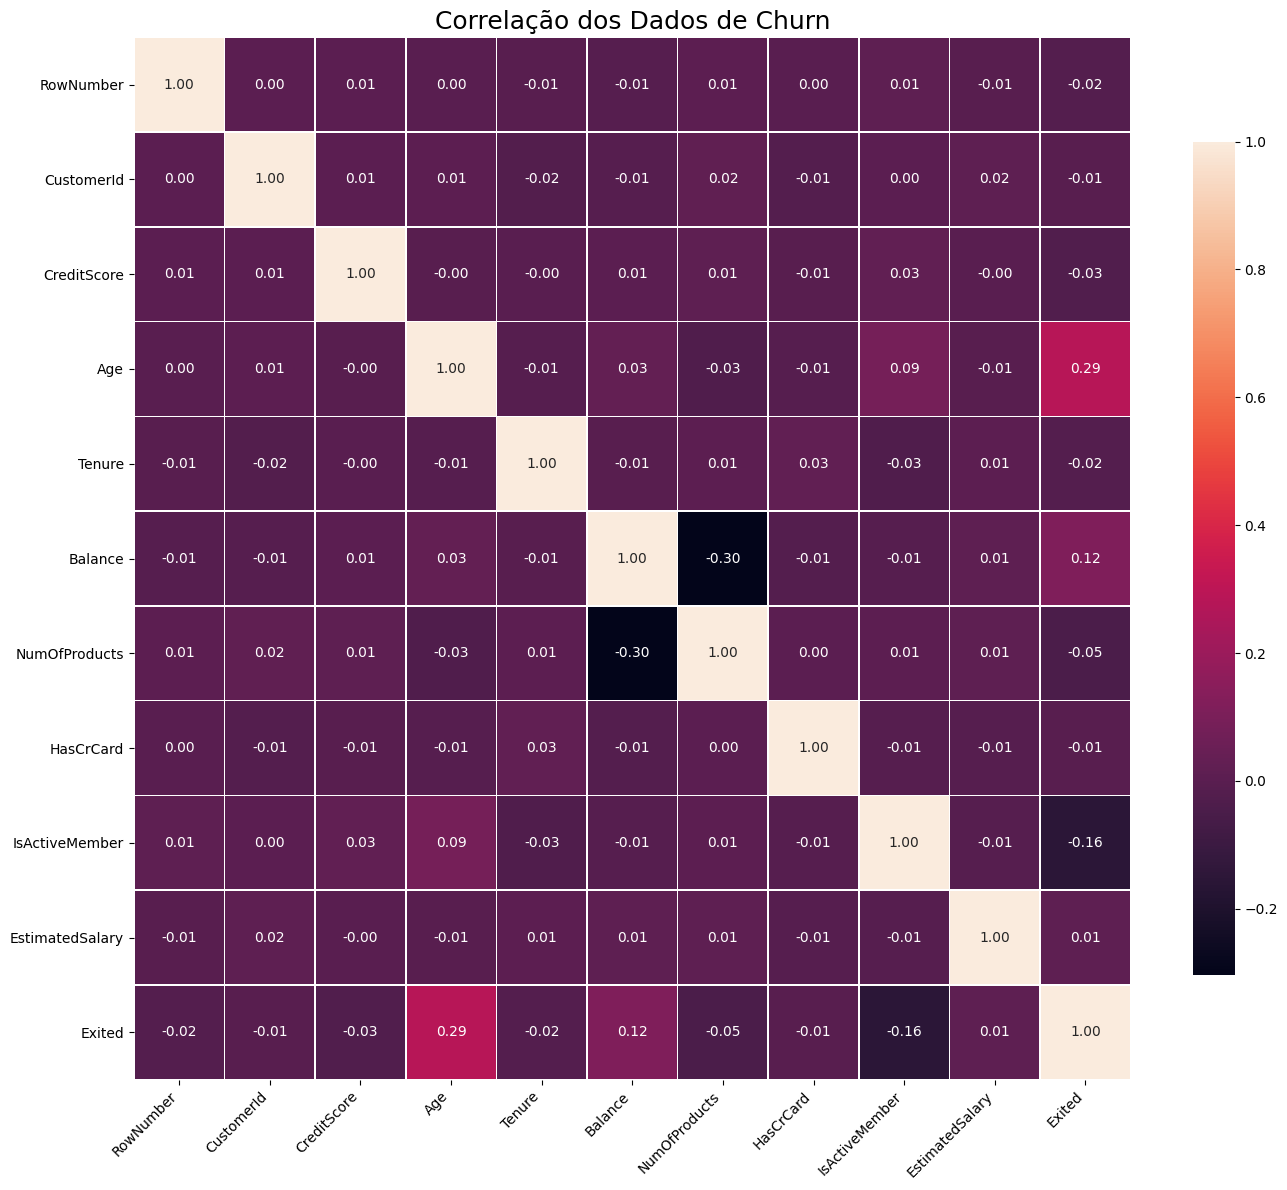

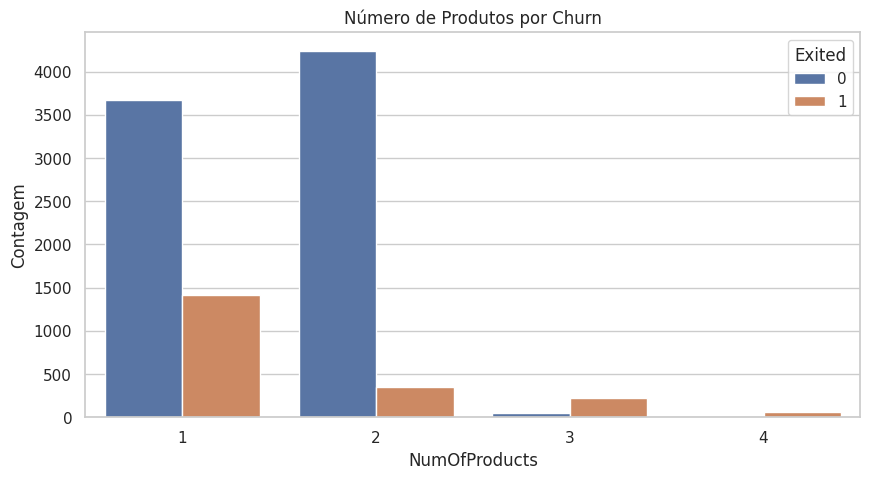

Você pode plotar também a distribuição de cada variável no conjunto de dados.
</s>
</div>

In [7]:
# Check the missing values
churn.isnull().sum()

row_number            0
customer_id           0
surname               0
creditscore           0
country               0
gender                0
age                   0
tenure              909
balance               0
num_of_products       0
has_crcard            0
is_active_member      0
estimated_salary      0
churn                 0
dtype: int64

In [8]:
# count duplicates
churn.duplicated().sum()

0

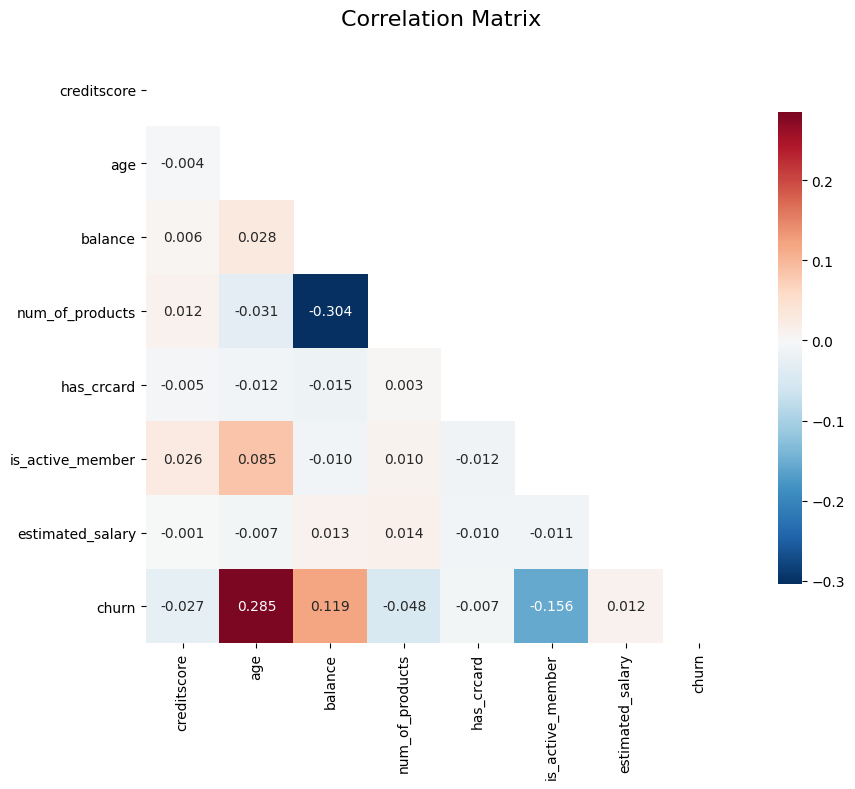

In [9]:
# Seletc only numerics 
numeric_cols = ['creditscore', 'age', 'balance', 'num_of_products', 
                'has_crcard', 'is_active_member', 'estimated_salary', 'churn']

# Corrlation Matrix
correlation_matrix = churn[numeric_cols].corr()

# Graphic
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# heatmap
sns.heatmap(correlation_matrix, 
            mask=mask,
            annot=True, 
            cmap='RdBu_r', 
            center=0,
            square=True,
            fmt='.3f',
            cbar_kws={"shrink": .8})

plt.title('Correlation Matrix', fontsize=16, pad=20)
plt.tight_layout()
plt.show()


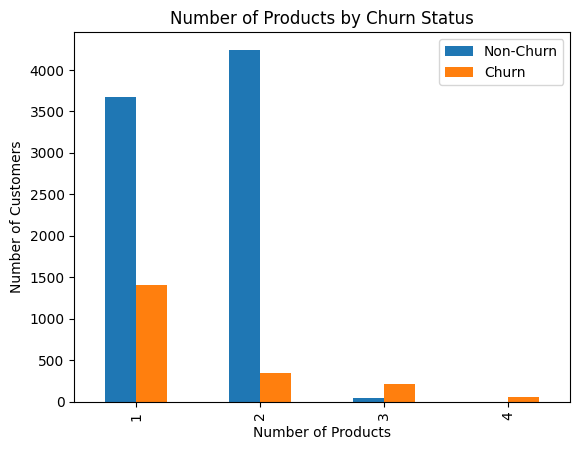

In [10]:
#group by
product_churn = (
    churn
    .groupby(['num_of_products', 'churn'])
    .size()
    .unstack(fill_value=0)
)

# plot
product_churn.plot(kind='bar')

plt.xlabel('Number of Products')
plt.ylabel('Number of Customers')
plt.title('Number of Products by Churn Status')
plt.legend(['Non-Churn', 'Churn'])
plt.show()


<div class="alert alert-block alert-info">

<b> Ambros Graficos criados.</b> <a class="tocSkip"></a>
</div>



2) Train the model without considering class imbalance

In [11]:
# Contar quantos clientes saíram vs ficaram
print(churn['churn'].value_counts())
print(churn['churn'].value_counts(normalize=True))

0    7963
1    2037
Name: churn, dtype: int64
0    0.7963
1    0.2037
Name: churn, dtype: float64


In [12]:
# Simple model
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


# Separate features/target
features = churn.drop(columns=['surname', 'tenure'])
target = churn['churn']

# One-Hot Encoding for categorical columns
features = pd.get_dummies(features, columns=['country', 'gender'], drop_first=True)

# Split
features_train, features_valid, target_train, target_valid = train_test_split(features, target, test_size=0.25, random_state=12345) 

# Model
model = RandomForestClassifier(random_state=42)
model.fit(features_train, target_train)

#Metrics
preds = model.predict(features_valid)
acc = accuracy_score(target_valid, preds)

print(f"Accuracy: {acc:.4f}")


Accuracy: 1.0000


<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>
    
O modelo `baseline` sem levar em conta o desbalanceamento das classes foi treinado.
    
</div>

A Random Forest model was trained without handling class imbalance and evaluated using accuracy. The model achieved an accuracy of 1.0, which is unusually high for a churn prediction problem. This suggests that accuracy alone may be misleading in an imbalanced dataset, and additional metrics are needed to properly evaluate the model.

3)Improving the model

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score

# Separate features/target
features = churn.drop(columns=['churn', 'surname', 'tenure'])
target = churn['churn']

# One-Hot Encoding
features = pd.get_dummies(features, columns=['country', 'gender'], drop_first=True)

# Split
features_train, features_valid, target_train, target_valid = train_test_split(
    features, target, test_size=0.25, random_state=12345, stratify=target
)

# model 
model = LogisticRegression(
    random_state=12345,
    solver='liblinear',
    max_iter=2000
)

# Grid of hyperparameters
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'class_weight': [None, 'balanced']
}

# GridSearch
grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

# training data
grid.fit(features_train, target_train)

print("Best parameters:", grid.best_params_)
print("Best CV F1:", grid.best_score_)

# Best model from GridSearch
best_model = grid.best_estimator_

# Predictions on validation set
predicted_valid = best_model.predict(features_valid)
proba_valid = best_model.predict_proba(features_valid)[:, 1]

# Metrics
f1_class_weight = f1_score(target_valid, predicted_valid)
acc_class_weight = accuracy_score(target_valid, predicted_valid)
auc_class_weight = roc_auc_score(target_valid, proba_valid)

print("F1:", f1)
print("Accuracy:", acc)
print("AUC:", auc)


/.venv/lib/python3.9/site-packages/sklearn/svm/_base.py:985: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn("Liblinear failed to converge, increase "
/.venv/lib/python3.9/site-packages/sklearn/svm/_base.py:985: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn("Liblinear failed to converge, increase "


<div class="alert alert-block alert-warning">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

Aqui você pode usar o método `Gridsearch` para fazer o estudo de hiperparâmetros de forma automatizada.
</div>

In [ ]:
# Undersampling

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

# Separate features/target
features = churn.drop(columns=['churn', 'surname', 'tenure'])
target = churn['churn']

#  Split
features_train, features_valid, target_train, target_valid = train_test_split(
    features, target, test_size=0.25, random_state=12345, stratify=target
)

# OHE em train e valid com alinhamento de colunas
features_train = pd.get_dummies(features_train, columns=['country', 'gender'], drop_first=True)
features_valid = pd.get_dummies(features_valid, columns=['country', 'gender'], drop_first=True)

# garantir mesmas colunas
features_valid = features_valid.reindex(columns=features_train.columns, fill_value=0)

def downsample(features, target, fraction):
    features_zeros = features[target == 0]
    features_ones = features[target == 1]
    target_zeros = target[target == 0]
    target_ones = target[target == 1]

    features_downsampled = pd.concat([
        features_zeros.sample(frac=fraction, random_state=12345),
        features_ones
    ])
    target_downsampled = pd.concat([
        target_zeros.sample(frac=fraction, random_state=12345),
        target_ones
    ])

    features_downsampled, target_downsampled = shuffle(
        features_downsampled, target_downsampled, random_state=12345
    )
    return features_downsampled, target_downsampled

# Downsample
features_downsampled, target_downsampled = downsample(
    features_train, target_train, 0.1
)

# Treinar e avaliar
model = LogisticRegression(random_state=12345, solver='liblinear', max_iter=1000)
model.fit(features_downsampled, target_downsampled)


# Predict (class + probability)

predicted_valid = model.predict(features_valid)
proba_valid = model.predict_proba(features_valid)[:, 1]



# Metrics

f1_undersampling = f1_score(target_valid, predicted_valid)
acc_undersampling = accuracy_score(target_valid, predicted_valid)
auc_undersampling = roc_auc_score(target_valid, proba_valid)



print("F1:", f1_undersampling)
print("Accuracy:", acc_undersampling)
print("AUC:", auc_undersampling)


In [ ]:
#compare results
import pandas as pd

results_comparison = pd.DataFrame({
    'Método': ['Class Weight', 'Undersampling'],
    'F1-Score': [f1_class_weight, f1_undersampling],  
    'AUC-ROC': [auc_class_weight, auc_undersampling]  
})

print("COMPARAÇÃO DE MÉTODOS:")
print(results_comparison)


<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

Os métodos usando `class_weight` e `undersampling` foram analisados e comparados.
</div>

These results indicate that class imbalance does affect model performance, and that class weighting is a more effective strategy than undersampling for this dataset. Undersampling likely removed too much useful information, negatively impacting the model’s ability to learn meaningful patterns.


The next step will be to perform hyperparameter tuning to assess whether model performance can be improved.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score

# Separate features/target
features = churn.drop(columns=['churn', 'surname', 'tenure'])
target = churn['churn']

# One-Hot Encoding
features = pd.get_dummies(features, columns=['country', 'gender'], drop_first=True)

# Split
features_train, features_valid, target_train, target_valid = train_test_split(
    features, target, test_size=0.25, random_state=12345, stratify=target
)

# Hyperparameters 
model = RandomForestClassifier(
    n_estimators=200,        
    max_depth=10,           
    min_samples_leaf=5,     
    class_weight='balanced',
    random_state=12345
)

model.fit(features_train, target_train)

# Predictions
pred_valid = model.predict(features_valid)
proba_valid = model.predict_proba(features_valid)[:, 1]

# Metrics
f1 = f1_score(target_valid, pred_valid)
acc = accuracy_score(target_valid, pred_valid)
auc = roc_auc_score(target_valid, proba_valid)

print("F1:", f1)
print("Accuracy:", acc)
print("AUC:", auc)

print("\nAccuracy (train):", model.score(features_train, target_train))
print("Accuracy (valid):", model.score(features_valid, target_valid))


<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

- Pelo menos duas técnicas para lidar com desbalanceamento dos dados foram estudadas
- Os modelos foram treinados nos dados reamostrados
- A performance foi calculada no conjunto de validação 
</div>

After hyperparameter tuning, the model performance improved significantly. The Random Forest achieved an F1-score of 0.63 and an AUC-ROC of 0.87 on the validation set, indicating good class separation and a balanced trade-off between precision and recall. The small gap between training and validation accuracy suggests that the model generalizes well.

4) Final Test

In [ ]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score, classification_report

# Separate features/target
X = churn.drop(columns=['churn', 'surname', 'tenure'])
y = churn['churn']

# One-Hot Encoding
X = pd.get_dummies(X, columns=['country', 'gender'], drop_first=True)

# slipt
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=12345, stratify=y
)

X_train_final, X_valid_final, y_train_final, y_valid_final = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=12345, stratify=y_temp
)

print("Data split:")
print(f"Training: {len(X_train_final)} samples")
print(f"Validation: {len(X_valid_final)} samples")
print(f"Test: {len(X_test)} samples")

In [ ]:

# 3. Traning Model with the better hypameter
final_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=12345
)


final_model.fit(X_train_final, y_train_final)


valid_pred = final_model.predict(X_valid_final)
valid_proba = final_model.predict_proba(X_valid_final)[:, 1]

valid_f1 = f1_score(y_valid_final, valid_pred)
valid_auc = roc_auc_score(y_valid_final, valid_proba)

print(f"Validação - F1: {valid_f1:.4f}, AUC: {valid_auc:.4f}")

In [ ]:
# Make predictions on the test set
test_pred = final_model.predict(X_test)
test_proba = final_model.predict_proba(X_test)[:, 1]

# Calculate final metrics
final_f1 = f1_score(y_test, test_pred)
final_auc = roc_auc_score(y_test, test_proba)
final_accuracy = accuracy_score(y_test, test_pred)

print("\nFINAL PROJECT RESULTS:")
print(f"F1-score: {final_f1:.4f}")
print(f"AUC-ROC: {final_auc:.4f}")
print(f"Accuracy: {final_accuracy:.4f}")

if final_f1 >= 0.59:
    print(f"\nSUCCESS! F1-score ({final_f1:.4f}) is above the minimum threshold (0.59)")
else:
    print(f"\nF1-score ({final_f1:.4f}) is below the minimum threshold (0.59)")


<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

- O melhor modelo foi testado no conjunto de testes
- A performance de pelo menos `0.59` de F1 foi atingida no conjunto de teste

</div>